In [32]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
import rfitools
import numba as nb
import importlib
importlib.reload(rfitools)
import time

In [33]:
deltat = 0.5 #sec
deltaf = 4768.37158203 #Hz

In [34]:
fstart = 21972656.25 # Hz

In [35]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
        # 7: [79.41540905, -90.77299123, 180.4816], #MARS3
        # 8: [79+24/60+28.80/3600, -90 - 48/60 - 5.09/3600, 200]
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [36]:
nant=len(coords)
triu_idx=np.triu_indices(nant,k=1)
nbl = len(triu_idx[0])

In [37]:
tstart = 1753264834.1802247
tend = tstart + 5
ntime = np.round((tend-tstart)/deltat).astype(int)
times = np.arange(ntime)*deltat + tstart
print(times[0], ntime, times[-1])

1753264834.1802247 10 1753264838.6802247


In [38]:
obstime=Time(times,format="unix",scale="utc")

ras = ['23h23m27.94s', '19h 59m 28.3566s']
decs = ['58d48m42.4s', "40° 44′ 02.096″"]
sources = SkyCoord(ra=ras,dec=decs , frame='icrs')
source_azalt = np.zeros((len(sources), 2, len(obstime)), dtype='float64')
for i,src in enumerate(sources):
    azalt = src.transform_to(AltAz(location=ant0,obstime=obstime))
    source_azalt[i, 0, :] = azalt.az.rad
    source_azalt[i, 1, :] = azalt.alt.rad

In [39]:
source_azalt.shape

(2, 2, 10)

In [40]:
bl_enus = rfitools.get_all_bls(coords,np.arange(len(coords)))

(21, 3)


In [41]:
delays0 = rfitools.geo_delay_from_enu(bl_enus, source_azalt[0,0], source_azalt[0,1])
delays1 = rfitools.geo_delay_from_enu(bl_enus, source_azalt[1,0], source_azalt[1,1])

In [42]:
delays0.shape

(21, 10)

In [43]:
#baseline lengths
bl_lengths = np.sqrt(np.sum(bl_enus*bl_enus,axis=1))
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(antmap[ai], antmap[aj], i,ai,aj, bl_lengths[i])

MARS1 MARS2 0 0 1 174.45456775051662
MARS1 MARS4 1 0 2 6089.384461074008
MARS1 MARS5 2 0 3 2055.7884567985097
MARS1 MARS6 3 0 4 2248.2290395629816
MARS1 MARS7 4 0 5 1614.993536696582
MARS1 MARS8 5 0 6 3143.2792581319386
MARS2 MARS4 6 1 2 6240.3838025376035
MARS2 MARS5 7 1 3 1881.5962163339905
MARS2 MARS6 8 1 4 2309.689734452764
MARS2 MARS7 9 1 5 1458.5268016563846
MARS2 MARS8 10 1 6 3088.474324240012
MARS4 MARS5 11 2 3 7956.833009844907
MARS4 MARS6 12 2 4 4633.21326925574
MARS4 MARS7 13 2 5 7133.9978322114575
MARS4 MARS8 14 2 6 8741.141688683856
MARS5 MARS6 15 3 4 3541.1607982782593
MARS5 MARS7 16 3 5 953.4344496617705
MARS5 MARS8 17 3 6 3047.6686048967063
MARS6 MARS7 18 4 5 2623.064250068337
MARS6 MARS8 19 4 6 5391.147752404277
MARS7 MARS8 20 5 6 3655.4414760084646


block size 128

In [44]:
freqs = np.arange(100) * deltaf + fstart #Hz
nfreq = len(freqs)

In [45]:
vis = np.zeros((ntime, nbl, nfreq),dtype='complex64')

In [46]:
delays0.shape

(21, 10)

In [47]:
d0 = delays0[:,0].copy()
d1 = delays1[:,0].copy()

In [48]:

# vis = 66 * np.exp(-2j*np.pi*d0[:,None] * freqs[None, :]) +\
#       37 * np.exp(-2j*np.pi*d1[:,None] * freqs[None, :]) #casA 66,000 Jy, cyg A 37,000 Jy

vis = 66 * np.exp(-2j*np.pi*delays0.T[:,:,None] * freqs[None, None, :]) +\
      37 * np.exp(-2j*np.pi*delays1.T[:,:,None] * freqs[None, None, :]) #casA 66,000 Jy, cyg A 37,000 Jy

In [49]:
vis.shape

(10, 21, 100)

In [50]:
#Let's time makin a map for one time to make sure vis sim is good
NSIDE=256
NPIX=hp.nside2npix(NSIDE)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)
co_dec,ra=hp.pix2ang(NSIDE,np.arange(NPIX))
dec=np.pi/2-co_dec

src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz_hp =src.transform_to(AltAz(location=ant0,obstime=obstime[0]))
delays = rfitools.geo_delay_from_enu(bl_enus, altaz_hp.az.rad, altaz_hp.alt.rad)

resol 13.741945647269624 npix 786432


In [51]:
vis.shape

(10, 21, 100)

In [52]:
delaysT = delays[:,:].T.copy() #exclude MARS1-2
data = vis[0, :, :].T.copy()
# data = vis.T.copy()

In [53]:
data.shape, delaysT.shape

((100, 21), (786432, 21))

In [54]:
@nb.njit(parallel=True)
def get_map(data,freqs,delays,npix):
    print(data.shape, freqs.shape, delays.shape)
    map1 = np.zeros(npix, dtype=np.float64)
    nfreq, nbl = data.shape
    N_vis = nfreq * nbl
    for p in nb.prange(npix):
        pixel_sum = 0.
        for f in range(nfreq):
            nu = freqs[f]
            for b in range(nbl):
                tau = delays[p, b] #delay shape is npix, nbl for CPU

                # Calculate the fringe factor for this specific visibility
                fringe = np.exp(2j * np.pi * nu * tau)
                
                # Accumulate the dot product
                pixel_sum += fringe.real * data[f, b].real - fringe.imag * data[f, b].imag
        
        # Calculate the mean and assign to the pixel map
        map1[p] = pixel_sum / N_vis
    return map1

In [55]:
t1=time.time()
map1 = get_map(data,freqs,delaysT,100)
t2=time.time()
print(t2-t1)

(100, 21) (100,) (786432, 21)
0.42203378677368164


In [56]:
t1=time.time()
map1 = get_map(data,freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(100, 21) (100,) (786432, 21)
5.992953300476074


In [57]:
freqs.shape

(100,)

In [58]:
np.savez('/scratch/thomasb/mapmaking_dumps/simulation_vis.npz', vis=vis, delays=delays, freqs=freqs, times = times, mask = np.zeros_like(vis, dtype=bool))

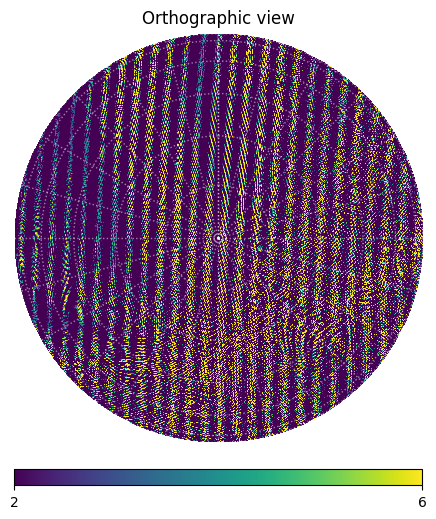

In [59]:
hp.orthview(map1,min=2,max=6,rot=(0,90),half_sky=True)
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

In [105]:
map_gpu = np.load("./output/test_map_onetime.npy")

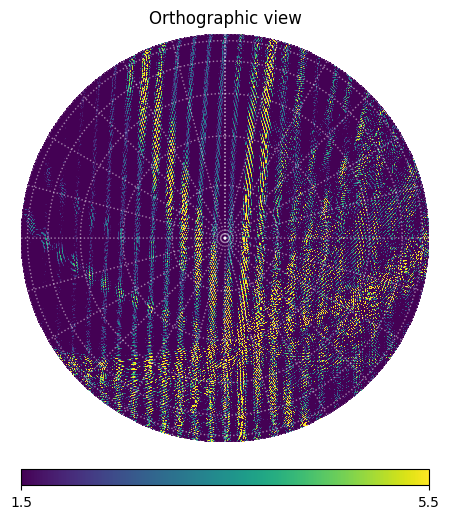

In [106]:
hp.orthview(map_gpu, min=1.5, max=5.5, rot=(0,90),half_sky=True)
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

In [20]:
ha,dec = rfitools.azalt_to_hadec(altaz_hp.az.rad,altaz_hp.alt.rad,ant0.lat.rad) #apparent ha dec at time zero

In [21]:
gha = ha - ant0.lon.rad
cos_dec = np.cos(dec)
sin_dec = np.sin(dec)
cos_gha = np.cos(gha)
sin_gha = np.sin(gha)
# Unit vectors of source in ITRS (ECEF)
u0 = cos_dec * cos_gha  # greenwich (Lat=0, Lon=0)
u1 = -cos_dec * sin_gha # ~malaysia (Lat=0, Lon=90E)
u2 = sin_dec
dir_cosines = np.empty((3, NPIX), dtype='float32')
dir_cosines[0,:]=u0
dir_cosines[1,:]=u1
dir_cosines[2,:]=u2

In [22]:
bl_itrs = rfitools.get_all_bls(coords,np.arange(len(coords)),enu=False)

(21, 3)


In [22]:
np.savez("./output/test_viz_alltimes.npz", vis=vis, dir_cosines=dir_cosines, freqs=freqs, dt=deltat, df=deltaf, bls=bl_itrs)

In [23]:
np.savez("./output/test_viz_alltimes_profile.npz", vis=vis, dir_cosines=dir_cosines, freqs=freqs, dt=deltat, df=deltaf, bls=bl_itrs)

In [24]:
vis.shape

(10, 21, 100)

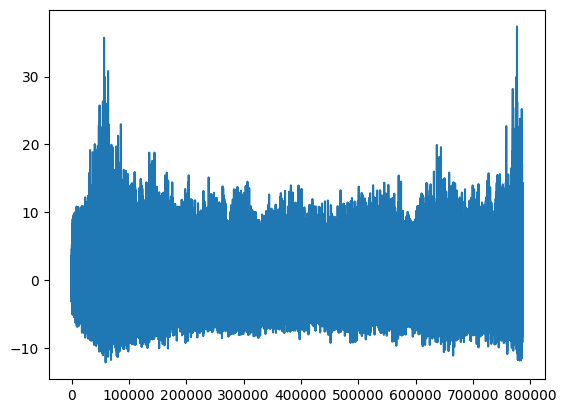

In [107]:
map_gpu2 = np.load("./output/test_map_alltimes.npy")
plt.plot(map_gpu2)

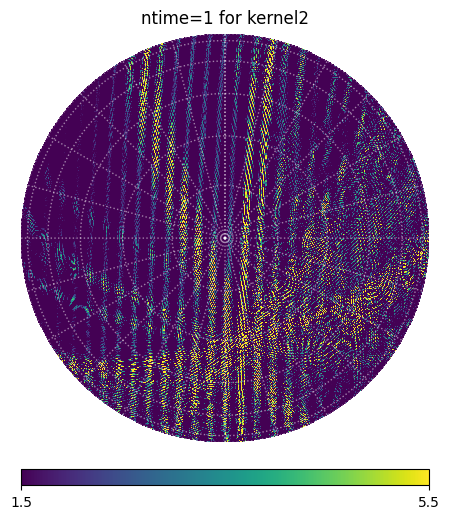

In [109]:
hp.orthview(map_gpu2, min = 1.5, max=5.5, rot=(0,90),half_sky=True, title="ntime=1 for kernel2")
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

In [25]:
map_gpu2.shape

(12582912,)

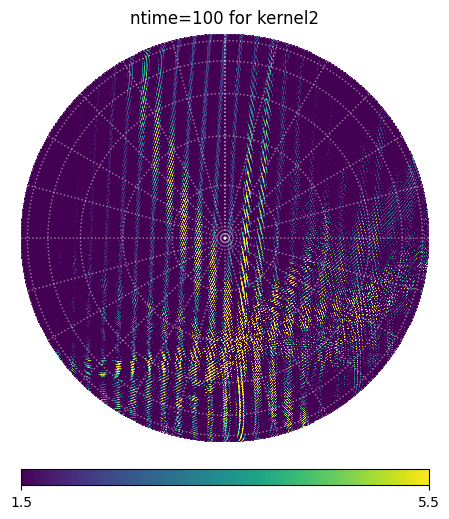

In [27]:
map_gpu2 = np.load("./output/test_map_alltimes_big.npy")
hp.orthview(map_gpu2, min = 1.5, max=5.5, rot=(0,90),half_sky=True, title="ntime=100 for kernel2")
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

In [107]:
map_gpu

array([-1890186., -1890186., -1890186., ..., -1890186., -1890186.,
       -1890186.], shape=(786432,), dtype=float32)

In [112]:
dir_cosines[:, [100000,200000,300000,400000,500000,600000,700000]]

array([[ 0.41897187, -0.80350655,  0.18387003,  0.71083415, -0.9418521 ,
         0.32006502, -0.4174689 ],
       [ 0.38127095,  0.24769005, -0.98053044,  0.695435  ,  0.24015616,
        -0.68571115, -0.32252735],
       [-0.82407224, -0.54131955, -0.06893414, -0.10528534,  0.23503126,
         0.65372676,  0.8495268 ]], dtype=float32)

In [114]:
bl_itrs

array([[ 1.74388171e+02,  2.59033857e+00, -4.05611443e+00],
       [-5.22307621e+03, -3.03948069e+03, -7.49423229e+02],
       [ 2.04952154e+03,  1.23165282e+02, -1.02751796e+02],
       [-6.97699946e+02, -2.06856726e+03, -5.37380752e+02],
       [ 1.46892899e+03, -6.14309099e+02, -2.70325876e+02],
       [ 1.04179716e+03,  2.86448538e+03,  7.67845466e+02],
       [-5.39746438e+03, -3.04207103e+03, -7.45367115e+02],
       [ 1.87513337e+03,  1.20574943e+02, -9.86956818e+01],
       [-8.72088117e+02, -2.07115760e+03, -5.33324637e+02],
       [ 1.29454082e+03, -6.16899438e+02, -2.66269762e+02],
       [ 8.67408990e+02,  2.86189504e+03,  7.71901580e+02],
       [ 7.27259775e+03,  3.16264597e+03,  6.46671433e+02],
       [ 4.52537626e+03,  9.70913427e+02,  2.12042477e+02],
       [ 6.69200520e+03,  2.42517159e+03,  4.79097353e+02],
       [ 6.26487337e+03,  5.90396607e+03,  1.51726869e+03],
       [-2.74722149e+03, -2.19173255e+03, -4.34628956e+02],
       [-5.80592555e+02, -7.37474381e+02

In [115]:
1/299792458

3.3356409519815204e-09

In [118]:
vis[199, 19, 109]

np.complex128(5.657261599826732+102.79950440028392j)

In [72]:
bl_itrs = rfitools.get_all_bls(coords,np.arange(len(coords)),enu=False)
bl_enu = rfitools.get_all_bls(coords,np.arange(len(coords)),enu=True)

(21, 3)
(21, 3)


In [73]:
bl_itrs-bl_enu

array([[ 5.03207172e-02, -1.50619240e+00,  8.35561739e-01],
       [-4.11682669e+01,  1.54418210e+02, -5.83763866e+02],
       [ 1.83298929e+00, -6.00026013e+00,  2.59106430e+01],
       [-2.77615809e+01,  7.25094960e+01, -3.90729098e+02],
       [-8.09417149e+00,  1.98088956e+01, -1.13797682e+02],
       [ 3.84501259e+01, -1.05756786e+02,  5.41658202e+02],
       [-4.12185876e+01,  1.55924402e+02, -5.84599428e+02],
       [ 1.78266857e+00, -4.49406773e+00,  2.50750813e+01],
       [-2.78119016e+01,  7.40156884e+01, -3.91564660e+02],
       [-8.14449221e+00,  2.13150880e+01, -1.14633244e+02],
       [ 3.83998052e+01, -1.04250594e+02,  5.40822641e+02],
       [ 4.30012562e+01, -1.60418470e+02,  6.09674509e+02],
       [ 1.34066860e+01, -8.19087136e+01,  1.93034768e+02],
       [ 3.30740954e+01, -1.34609314e+02,  4.69966184e+02],
       [ 7.96183928e+01, -2.60174996e+02,  1.12542207e+03],
       [-2.95945702e+01,  7.85097561e+01, -4.16639741e+02],
       [-9.92716078e+00,  2.58091557e+01

In [83]:
#Let's time makin a map for one time to make sure vis sim is good
NSIDE=256
NPIX=hp.nside2npix(NSIDE)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)
co_dec,ra=hp.pix2ang(NSIDE,np.arange(NPIX))
dec=np.pi/2-co_dec

src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz_hp =src.transform_to(AltAz(location=ant0,obstime=obstime[0]))
delays = rfitools.geo_delay_from_enu(bl_enus, altaz_hp.az.rad, altaz_hp.alt.rad)
ha,dec = rfitools.azalt_to_hadec(altaz_hp.az.rad,altaz_hp.alt.rad,ant0.lat.rad) #apparent ha dec at time zero
delays2 = rfitools.geo_delay_from_itrs(bl_itrs, ha, dec, ant0.lon.rad)
np.max(np.abs(delays-delays2))

resol 13.741945647269624 npix 786432


np.float64(9.825582188149884e-19)

In [84]:
gha = ha - ant0.lon.rad
cos_dec = np.cos(dec)
sin_dec = np.sin(dec)
cos_gha = np.cos(gha)
sin_gha = np.sin(gha)
# Unit vectors of source in ITRS (ECEF)
u0 = cos_dec * cos_gha  # greenwich (Lat=0, Lon=0)
u1 = -cos_dec * sin_gha # ~malaysia (Lat=0, Lon=90E)
u2 = sin_dec
dir_cosines = np.empty((3, NPIX), dtype='float32')
dir_cosines[0,:]=u0
dir_cosines[1,:]=u1
dir_cosines[2,:]=u2

In [85]:
l,m,n = dir_cosines[:,500000]
newdelays = np.zeros((nbl, ntime),dtype='float64')
for t in range(ntime):
    ph = t * 7.29211e-5
    sint = np.sin(ph)
    cost = np.cos(ph)
    # print("----",cost, sint,"----")
    for b in range(nbl):
        bx,by,bz = bl_itrs[b]
        bx2 = bx*cost - sint*by # 2d active rotation
        by2 = sint*bx + cost*by
        newdelays[b, t] = (l*bx2 + m*by2 + n*bz)/299792458

In [86]:
newdelays[:,0]

array([-5.48901573e-07,  1.89194737e-05, -6.45439428e-06,  3.87246893e-06,
       -4.04678129e-06, -5.62288553e-06,  1.94683753e-05, -5.90549271e-06,
        4.42137050e-06, -3.49787971e-06, -5.07398395e-06, -2.53738680e-05,
       -1.50470048e-05, -2.29662550e-05, -2.45423593e-05,  1.03268632e-05,
        2.40761299e-06,  8.31508751e-07, -7.91925021e-06, -9.49535445e-06,
       -1.57610424e-06])

In [88]:
delays[:,500000]

array([-5.48901572e-07,  1.89194737e-05, -6.45439427e-06,  3.87246888e-06,
       -4.04678129e-06, -5.62288547e-06,  1.94683752e-05, -5.90549270e-06,
        4.42137046e-06, -3.49787972e-06, -5.07398390e-06, -2.53738679e-05,
       -1.50470048e-05, -2.29662550e-05, -2.45423591e-05,  1.03268632e-05,
        2.40761298e-06,  8.31508800e-07, -7.91925018e-06, -9.49535435e-06,
       -1.57610418e-06])